# 🦴 Fracture Detection — DETR (DEtection TRansformer) Approach

**Dataset Kaggle** : `aymenouerghi07/fracture-dataset/fracture_research_dataset`  
**7 classes** : fracture_elbow · fracture_humerus · fracture_finger · fracture_forearm · fracture_femur · normal · fracture_leg  

**Architecture** : DETR (Facebook Research) — Transformer-based end-to-end object detection  
**Backbone** : ResNet-50 pré-entraîné ImageNet  

**Fixes appliqués :**
- ✅ Category IDs 1-based (DETR HuggingFace convention)
- ✅ NMS + top-1 box par image (visualisation propre)
- ✅ `assign=True` dans `load_state_dict`
- ✅ `conf_threshold=0.01` pour évaluation après peu d'epochs
- ✅ Résumé final robuste (gestion None)

---

## ⚙️ Étape 0 — Dépendances & imports

In [1]:
# ── Installations ──────────────────────────────────────────────────────────
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118 -q
!pip install transformers datasets pycocotools timm scipy -q
!pip install Pillow matplotlib pyyaml -q

# ── Imports standard ────────────────────────────────────────────────────────
import os
import json
import random
import shutil
import yaml
import math
import copy
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# ── PyTorch ─────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.ops import nms as torchvision_nms
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF

# ── HuggingFace Transformers (DETR) ─────────────────────────────────────────
from transformers import (
    DetrImageProcessor,
    DetrForObjectDetection,
    DetrConfig,
)

# ── COCO evaluation ─────────────────────────────────────────────────────────
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

print('✅ Imports OK')
print(f'PyTorch version    : {torch.__version__}')
print(f'Torchvision version: {torchvision.__version__}')
print(f'CUDA disponible    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU                : {torch.cuda.get_device_name(0)}')

✅ Imports OK
PyTorch version    : 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA disponible    : True
GPU                : Tesla T4


## 📂 Étape 1 — Chemins & constantes

> **Identiques à la baseline YOLOv8n** — même dataset, même splits, même classes.

In [2]:
# ── Chemins Kaggle ──────────────────────────────────────────────────────────
DATASET_ROOT = Path('/kaggle/input/datasets/aymenouerghi07/fracture-dataset/fracture_research_dataset')
WORK_DIR     = Path('/kaggle/working/fracture_ds')      # données downsamplees
COCO_DIR     = Path('/kaggle/working/fracture_coco')    # conversion COCO JSON
OUTPUT_DIR   = Path('/kaggle/working/detr_output')      # checkpoints & logs

for d in [COCO_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Splits ──────────────────────────────────────────────────────────────────
SPLITS = ['train', 'valid', 'test']

# ── Classes ─────────────────────────────────────────────────────────────────
CLASS_NAMES = [
    'fracture_elbow',    # index 0
    'fracture_humerus',  # index 1
    'fracture_finger',   # index 2  ← classe sur-représentée
    'fracture_forearm',  # index 3
    'fracture_femur',    # index 4
    'normal',            # index 5
    'fracture_leg',      # index 6
]
NC              = len(CLASS_NAMES)
FINGER_CLASS_ID = 2

# ── FIX : DETR HuggingFace utilise des labels 1-indexés ─────────────────────
# post_process_object_detection retourne des labels 1..NC
# → id2label et label2id doivent donc être 1-based
ID2LABEL = {i + 1: name for i, name in enumerate(CLASS_NAMES)}  # {1: 'fracture_elbow', ..., 7: 'fracture_leg'}
LABEL2ID = {name: i + 1 for i, name in enumerate(CLASS_NAMES)}

# ── Couleurs ────────────────────────────────────────────────────────────────
COLORS = ['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4','#FFEAA7','#DDA0DD','#98D8C8']

print(f'Dataset source  : {DATASET_ROOT}')
print(f'Work dir        : {WORK_DIR}')
print(f'COCO dir        : {COCO_DIR}')
print(f'Output dir      : {OUTPUT_DIR}')
print(f'Classes ({NC})   : {CLASS_NAMES}')
print(f'ID2LABEL        : {ID2LABEL}')

if not DATASET_ROOT.exists():
    raise FileNotFoundError(f'Dataset introuvable : {DATASET_ROOT}')
print('✅ Dataset trouvé')

Dataset source  : /kaggle/input/datasets/aymenouerghi07/fracture-dataset/fracture_research_dataset
Work dir        : /kaggle/working/fracture_ds
COCO dir        : /kaggle/working/fracture_coco
Output dir      : /kaggle/working/detr_output
Classes (7)   : ['fracture_elbow', 'fracture_humerus', 'fracture_finger', 'fracture_forearm', 'fracture_femur', 'normal', 'fracture_leg']
ID2LABEL        : {1: 'fracture_elbow', 2: 'fracture_humerus', 3: 'fracture_finger', 4: 'fracture_forearm', 5: 'fracture_femur', 6: 'normal', 7: 'fracture_leg'}
✅ Dataset trouvé


## ⚖️ Étape 2 — Downsampling `fracture_finger` & data.yaml

> **Copié de la baseline** — on réutilise exactement la même logique de downsampling pour garantir la comparabilité des résultats.

In [3]:
# ── Utilitaires annotation ───────────────────────────────────────────────────
def count_annotations(root: Path, splits):
    global_counts = Counter()
    split_counts  = {}
    img_annot_map = {}
    for split in splits:
        lbl_dir = root / split / 'labels'
        if not lbl_dir.exists():
            split_counts[split] = Counter()
            continue
        sc = Counter()
        for lbl_file in lbl_dir.glob('*.txt'):
            ids_in_img = []
            with open(lbl_file) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cid = int(parts[0])
                        sc[cid] += 1
                        global_counts[cid] += 1
                        ids_in_img.append(cid)
            img_annot_map[f"{split}/{lbl_file.stem}"] = ids_in_img
        split_counts[split] = sc
    return global_counts, split_counts, img_annot_map


def get_label_classes(lbl_path: Path):
    classes = []
    if lbl_path.exists():
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    classes.append(int(parts[0]))
    return classes


def downsample_split(src_root, dst_root, split, class_id, target_count, seed=42):
    random.seed(seed)
    src_img = src_root / split / 'images'
    src_lbl = src_root / split / 'labels'
    dst_img = dst_root / split / 'images'
    dst_lbl = dst_root / split / 'labels'
    dst_img.mkdir(parents=True, exist_ok=True)
    dst_lbl.mkdir(parents=True, exist_ok=True)

    all_stems = [f.stem for f in src_lbl.glob('*.txt')]
    mixed_stems = []
    pure_finger_stems = []
    for stem in all_stems:
        classes = get_label_classes(src_lbl / f'{stem}.txt')
        has_finger = class_id in classes
        has_other  = any(c != class_id for c in classes)
        if has_finger and not has_other:
            pure_finger_stems.append(stem)
        else:
            mixed_stems.append(stem)

    mixed_finger_count = sum(
        get_label_classes(src_lbl / f'{s}.txt').count(class_id)
        for s in mixed_stems
    )
    remaining_target = max(0, target_count - mixed_finger_count)

    random.shuffle(pure_finger_stems)
    kept_pure = []
    finger_kept = 0
    for stem in pure_finger_stems:
        count = get_label_classes(src_lbl / f'{stem}.txt').count(class_id)
        if finger_kept + count <= remaining_target:
            kept_pure.append(stem)
            finger_kept += count

    kept_stems = mixed_stems + kept_pure
    removed    = len(all_stems) - len(kept_stems)

    for stem in kept_stems:
        for ext in ['.jpg', '.jpeg', '.png']:
            src = src_img / f'{stem}{ext}'
            if src.exists():
                shutil.copy(src, dst_img / f'{stem}{ext}')
                break
        shutil.copy(src_lbl / f'{stem}.txt', dst_lbl / f'{stem}.txt')

    finger_after = sum(
        get_label_classes(dst_lbl / f'{s}.txt').count(class_id)
        for s in kept_stems
    )
    return {
        'total_images'  : len(kept_stems),
        'removed_images': removed,
        'finger_before' : sum(get_label_classes(src_lbl / f'{s}.txt').count(class_id) for s in all_stems),
        'finger_after'  : finger_after,
    }


# ── Run downsampling ─────────────────────────────────────────────────────────
global_counts, split_counts, _ = count_annotations(DATASET_ROOT, SPLITS)

other_counts  = {cid: global_counts.get(cid, 0) for cid in range(NC) if cid != FINGER_CLASS_ID}
max_other     = max(other_counts.values())
TARGET_FINGER = min(max_other, global_counts.get(FINGER_CLASS_ID, 0))

split_img_counts = {}
for split in SPLITS:
    img_dir = DATASET_ROOT / split / 'images'
    split_img_counts[split] = len(list(img_dir.glob('*.[jp][pn]g'))) if img_dir.exists() else 0

total_img = sum(split_img_counts.values())
split_targets = {s: max(1, int(TARGET_FINGER * split_img_counts[s] / max(total_img, 1))) for s in SPLITS}

if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)
WORK_DIR.mkdir(parents=True, exist_ok=True)

print('⏳ Downsampling...')
for split in SPLITS:
    stats = downsample_split(DATASET_ROOT, WORK_DIR, split, FINGER_CLASS_ID, split_targets[split])
    print(f'  {split}: {stats["total_images"]} images gardées, '
          f'finger {stats["finger_before"]:,} → {stats["finger_after"]:,}')

print('\n✅ Downsampling terminé')

# ── Création du data.yaml ────────────────────────────────────────────────────
yaml_cfg = {
    'path' : str(WORK_DIR),
    'train': 'train/images',
    'val'  : 'valid/images',
    'test' : 'test/images',
    'nc'   : NC,
    'names': CLASS_NAMES,
}
YAML_PATH = WORK_DIR / 'data.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.dump(yaml_cfg, f, default_flow_style=False, allow_unicode=True)

print(f'✅ data.yaml créé : {YAML_PATH}')

⏳ Downsampling...
  train: 5737 images gardées, finger 24,264 → 1,234
  valid: 883 images gardées, finger 2,309 → 133
  test: 753 images gardées, finger 1,141 → 81

✅ Downsampling terminé
✅ data.yaml créé : /kaggle/working/fracture_ds/data.yaml


## 🔄 Étape 3 — Conversion YOLO → COCO JSON

DETR (via HuggingFace) attend les annotations au **format COCO JSON**.  
On convertit les labels YOLO (`.txt` avec bbox normalisées) en JSON COCO standard.

> **FIX** : `category_id` est maintenant **1-based** (convention COCO/DETR HuggingFace).

In [4]:
def yolo_to_coco(src_root: Path, split: str, class_names: list, out_json: Path):
    """
    Convertit les annotations YOLO (.txt, bbox normalisées xywh)
    en format COCO JSON (bbox absolues xywh).

    FIX : category_id est 1-based pour correspondre aux sorties de
    DetrForObjectDetection.post_process_object_detection().
    """
    img_dir = src_root / split / 'images'
    lbl_dir = src_root / split / 'labels'

    coco = {
        'info'       : {'description': f'Fracture Dataset — {split}'},
        'licenses'   : [],
        'images'     : [],
        'annotations': [],
        # ✅ FIX : category IDs démarrent à 1 (pas 0)
        'categories' : [
            {'id': i + 1, 'name': name, 'supercategory': 'fracture'}
            for i, name in enumerate(class_names)
        ],
    }

    img_id  = 0
    ann_id  = 0
    skipped = 0

    for lbl_file in sorted(lbl_dir.glob('*.txt')):
        img_path = None
        for ext in ['.jpg', '.jpeg', '.png']:
            p = img_dir / (lbl_file.stem + ext)
            if p.exists():
                img_path = p
                break
        if img_path is None:
            skipped += 1
            continue

        with Image.open(img_path) as im:
            W, H = im.size

        coco['images'].append({
            'id'       : img_id,
            'file_name': str(img_path.relative_to(src_root / split)),
            'width'    : W,
            'height'   : H,
        })

        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id         = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])

                abs_w = bw * W
                abs_h = bh * H
                abs_x = (cx - bw / 2) * W
                abs_y = (cy - bh / 2) * H

                coco['annotations'].append({
                    'id'          : ann_id,
                    'image_id'    : img_id,
                    'category_id' : cls_id + 1,  # ✅ FIX : YOLO 0-based → COCO 1-based
                    'bbox'        : [abs_x, abs_y, abs_w, abs_h],
                    'area'        : abs_w * abs_h,
                    'iscrowd'     : 0,
                })
                ann_id += 1

        img_id += 1

    out_json.parent.mkdir(parents=True, exist_ok=True)
    with open(out_json, 'w') as f:
        json.dump(coco, f)

    print(f'  [{split}] {img_id} images, {ann_id} annotations (skip={skipped})')
    return out_json


print('⏳ Conversion YOLO → COCO JSON...')
COCO_JSONS = {}
for split in SPLITS:
    out = COCO_DIR / f'{split}_annotations.json'
    COCO_JSONS[split] = yolo_to_coco(WORK_DIR, split, CLASS_NAMES, out)

print('\n✅ Conversion terminée')

⏳ Conversion YOLO → COCO JSON...
  [train] 5737 images, 3875 annotations (skip=0)
  [valid] 883 images, 441 annotations (skip=0)
  [test] 753 images, 276 annotations (skip=0)

✅ Conversion terminée


## 📦 Étape 4 — Dataset PyTorch pour DETR

In [5]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

class FractureCocoDataset(Dataset):
    def __init__(self, img_dir: Path, annotation_json: Path,
                 processor: DetrImageProcessor, augment: bool = False):
        self.img_dir   = img_dir
        self.processor = processor
        self.augment   = augment
        self.coco      = COCO(str(annotation_json))
        self.img_ids   = sorted(self.coco.imgs.keys())

    def __len__(self):
        return len(self.img_ids)

    def __getitem__(self, idx):
        img_id   = self.img_ids[idx]
        img_info = self.coco.imgs[img_id]

        img_path = self.img_dir / img_info['file_name']
        image    = Image.open(img_path).convert('RGB')
        W, H     = image.size

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns    = self.coco.loadAnns(ann_ids)

        if self.augment:
            image, anns = self._augment(image, anns, W, H)

        target = {
            'image_id': img_id,
            'annotations': [
                {
                    'image_id'    : img_id,
                    'category_id' : ann['category_id'],  # already 1-based from COCO JSON
                    'bbox'        : ann['bbox'],
                    'area'        : ann['area'],
                    'iscrowd'     : 0,
                }
                for ann in anns
            ]
        }

        encoding = self.processor(
            images=image,
            annotations=target,
            return_tensors='pt',
        )

        pixel_values = encoding['pixel_values'].squeeze(0)
        pixel_mask   = encoding['pixel_mask'].squeeze(0)
        labels       = encoding['labels'][0]

        labels['orig_size'] = torch.tensor([H, W], dtype=torch.long)

        return pixel_values, pixel_mask, labels

    def _augment(self, image, anns, W, H):
        if random.random() > 0.5:
            image = TF.hflip(image)
            for ann in anns:
                x, y, bw, bh = ann['bbox']
                ann['bbox'] = [W - (x + bw), y, bw, bh]

        jitter = T.ColorJitter(brightness=0.3, contrast=0.3,
                               saturation=0.3, hue=0.05)
        image = jitter(image)
        return image, anns


def collate_fn(batch):
    pixel_values_list = [item[0] for item in batch]
    pixel_mask_list   = [item[1] for item in batch]
    labels            = [item[2] for item in batch]

    max_h = max(t.shape[1] for t in pixel_values_list)
    max_w = max(t.shape[2] for t in pixel_values_list)

    padded_images = []
    padded_masks  = []
    for img, mask in zip(pixel_values_list, pixel_mask_list):
        c, h, w = img.shape
        pad_img  = torch.zeros(c, max_h, max_w, dtype=img.dtype)
        pad_mask = torch.zeros(max_h, max_w, dtype=mask.dtype)
        pad_img[:, :h, :w]  = img
        pad_mask[:h, :w]    = mask
        padded_images.append(pad_img)
        padded_masks.append(pad_mask)

    return {
        'pixel_values': torch.stack(padded_images),
        'pixel_mask'  : torch.stack(padded_masks),
        'labels'      : labels,
    }

print('✅ Classes Dataset & collate_fn définies')

✅ Classes Dataset & collate_fn définies


In [6]:
# ── Hyperparamètres ──────────────────────────────────────────────────────────
IMG_SIZE    = 800
BATCH_SIZE  = 4
NUM_WORKERS = 2

processor = DetrImageProcessor.from_pretrained(
    'facebook/detr-resnet-50',
    size={'shortest_edge': IMG_SIZE, 'longest_edge': IMG_SIZE},
)

train_dataset = FractureCocoDataset(
    img_dir         = WORK_DIR / 'train',
    annotation_json = COCO_JSONS['train'],
    processor       = processor,
    augment         = True,
)
val_dataset = FractureCocoDataset(
    img_dir         = WORK_DIR / 'valid',
    annotation_json = COCO_JSONS['valid'],
    processor       = processor,
    augment         = False,
)
test_dataset = FractureCocoDataset(
    img_dir         = WORK_DIR / 'test',
    annotation_json = COCO_JSONS['test'],
    processor       = processor,
    augment         = False,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train : {len(train_dataset):,} images ({len(train_loader)} batches)')
print(f'Val   : {len(val_dataset):,} images ({len(val_loader)} batches)')
print(f'Test  : {len(test_dataset):,} images ({len(test_loader)} batches)')

preprocessor_config.json:   0%|          | 0.00/290 [00:00<?, ?B/s]

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Train : 5,737 images (1435 batches)
Val   : 883 images (221 batches)
Test  : 753 images (189 batches)


## 🏗️ Étape 5 — Architecture DETR

**DETR** (DEtection TRansformer) est une architecture end-to-end qui supprime le besoin d'ancres et de NMS.  
Elle est composée de 3 modules clés :

```
Image
  │
  ▼
┌─────────────────────────────┐
│   CNN Backbone (ResNet-50)  │  → Feature maps (C, H/32, W/32)
└─────────────────────────────┘
  │
  ▼
┌─────────────────────────────────────────────────┐
│              Transformer Encoder                │  → 6 couches self-attention
└─────────────────────────────────────────────────┘
  │
  ▼
┌─────────────────────────────────────────────────┐
│              Transformer Decoder                │  → 6 couches cross-attention
│   N=100 object queries ──────────────────────►  │
└─────────────────────────────────────────────────┘
  │
  ▼
┌────────────────┐  ┌────────────────────────────┐
│  Class Head    │  │       BBox Head             │
│ Linear(d→NC+1) │  │  MLP(d→d→d→4) sigmoid      │
└────────────────┘  └────────────────────────────┘

Loss = Hungarian Matching + CE + L1 + GIoU
```

In [7]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ✅ FIX : id2label / label2id sont 1-based pour correspondre à DETR HuggingFace
detr_config = DetrConfig.from_pretrained(
    'facebook/detr-resnet-50',
    num_labels              = NC,
    id2label                = ID2LABEL,   # {1: 'fracture_elbow', ..., 7: 'fracture_leg'}
    label2id                = LABEL2ID,
    num_queries             = 100,
    d_model                 = 256,
    encoder_layers          = 6,
    decoder_layers          = 6,
    encoder_attention_heads = 8,
    decoder_attention_heads = 8,
    encoder_ffn_dim         = 2048,
    decoder_ffn_dim         = 2048,
    dropout                 = 0.1,
    class_cost              = 1,
    bbox_cost               = 5,
    giou_cost               = 2,
    dice_loss_coefficient   = 1,
    bbox_loss_coefficient   = 5,
    giou_loss_coefficient   = 2,
    backbone                = 'resnet50',
    dilation                = False,
    position_embedding      = 'sine',
)

model = DetrForObjectDetection.from_pretrained(
    'facebook/detr-resnet-50',
    config                  = detr_config,
    ignore_mismatched_sizes = True,
)
model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n📐 Architecture DETR-ResNet50')
print(f'   Paramètres totaux       : {total_params:,}')
print(f'   Paramètres entraînables : {trainable_params:,}')
print(f'   Object queries          : {detr_config.num_queries}')
print(f'   Transformer dim (d)     : {detr_config.d_model}')
print(f'   Encoder layers          : {detr_config.encoder_layers}')
print(f'   Decoder layers          : {detr_config.decoder_layers}')
print(f'   Classes                 : {NC} + 1 (no-object)')
print(f'   Device                  : {DEVICE}')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:2586: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  module._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  super()._load_from_state_dict(
/usr/local/lib/python3.12/dist-packages/torch/nn/modules/batchnorm.py:133: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, whi

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |                                                                                      
----------------------------------------------------------------------------+------------+--------------------------------------------------------------------------------------
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |                                                                                      
model.backbone.conv_encoder.model.layer2.0.downsam


📐 Architecture DETR-ResNet50
   Paramètres totaux       : 41,503,180
   Paramètres entraînables : 41,503,180
   Object queries          : 100
   Transformer dim (d)     : 256
   Encoder layers          : 6
   Decoder layers          : 6
   Classes                 : 7 + 1 (no-object)
   Device                  : cuda


## 🚀 Étape 6 — Entraînement DETR

**Stratégie d'optimisation** :
- `AdamW` avec **learning rates différenciés** : backbone (faible LR) vs transformer (LR standard)
- `LinearWarmup` + `CosineDecay`
- **Gradient clipping** (essentiel pour la stabilité DETR)
- Early stopping sur `val_loss`

In [8]:
# ── Hyperparamètres entraînement ─────────────────────────────────────────────
EPOCHS         = 7     # ← augmenter pour de meilleurs résultats (150+ idéal)
LR_BACKBONE    = 1e-5
LR_TRANSFORMER = 1e-4
WEIGHT_DECAY   = 1e-4
GRAD_CLIP      = 0.1
WARMUP_EPOCHS  = 5
PATIENCE       = 10

param_groups = [
    {
        'params': [p for n, p in model.named_parameters()
                   if 'backbone' in n and p.requires_grad],
        'lr': LR_BACKBONE,
    },
    {
        'params': [p for n, p in model.named_parameters()
                   if 'backbone' not in n and p.requires_grad],
        'lr': LR_TRANSFORMER,
    },
]
optimizer = optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(EPOCHS - WARMUP_EPOCHS, 1)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print('✅ Optimizer & Scheduler définis')
print(f'   Backbone    LR : {LR_BACKBONE}')
print(f'   Transformer LR : {LR_TRANSFORMER}')
print(f'   Gradient clipping : {GRAD_CLIP}')
print(f'   Epochs planifiés  : {EPOCHS}')

✅ Optimizer & Scheduler définis
   Backbone    LR : 1e-05
   Transformer LR : 0.0001
   Gradient clipping : 0.1
   Epochs planifiés  : 7


In [9]:
# ── Boucle d'entraînement ────────────────────────────────────────────────────
history = {
    'train_loss': [], 'val_loss': [],
    'train_loss_ce': [], 'train_loss_bbox': [], 'train_loss_giou': [],
}

best_val_loss  = float('inf')
patience_count = 0
BEST_CKPT      = OUTPUT_DIR / 'detr_best.pth'


def run_epoch(loader, training=True):
    model.train(training)
    total_loss  = 0.0
    total_ce    = 0.0
    total_bbox  = 0.0
    total_giou  = 0.0
    n_batches   = 0

    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            pixel_values = batch['pixel_values'].to(DEVICE)
            pixel_mask   = batch['pixel_mask'].to(DEVICE)
            labels       = [{k: v.to(DEVICE) for k, v in t.items()}
                            for t in batch['labels']]

            outputs = model(
                pixel_values=pixel_values,
                pixel_mask=pixel_mask,
                labels=labels,
            )

            loss      = outputs.loss
            loss_dict = outputs.loss_dict

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

            total_loss += loss.item()
            total_ce   += loss_dict.get('loss_ce',   torch.tensor(0.0)).item()
            total_bbox += loss_dict.get('loss_bbox',  torch.tensor(0.0)).item()
            total_giou += loss_dict.get('loss_giou',  torch.tensor(0.0)).item()
            n_batches  += 1

    return {
        'loss': total_loss / max(n_batches, 1),
        'ce'  : total_ce   / max(n_batches, 1),
        'bbox': total_bbox / max(n_batches, 1),
        'giou': total_giou / max(n_batches, 1),
    }


print(f'🚀 Début entraînement — {EPOCHS} epochs')
print(f'   Batch size : {BATCH_SIZE} | IMG size : {IMG_SIZE}')
print('=' * 72)

for epoch in range(1, EPOCHS + 1):
    train_metrics = run_epoch(train_loader, training=True)
    val_metrics_epoch = run_epoch(val_loader, training=False)

    scheduler.step()

    history['train_loss'].append(train_metrics['loss'])
    history['val_loss'].append(val_metrics_epoch['loss'])
    history['train_loss_ce'].append(train_metrics['ce'])
    history['train_loss_bbox'].append(train_metrics['bbox'])
    history['train_loss_giou'].append(train_metrics['giou'])

    lr_now = scheduler.get_last_lr()[1]
    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'Train {train_metrics["loss"]:.4f} '
          f'(ce={train_metrics["ce"]:.3f} '
          f'bbox={train_metrics["bbox"]:.3f} '
          f'giou={train_metrics["giou"]:.3f}) | '
          f'Val {val_metrics_epoch["loss"]:.4f} | '
          f'LR {lr_now:.2e}')

    if val_metrics_epoch['loss'] < best_val_loss:
        best_val_loss = val_metrics_epoch['loss']
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss'   : best_val_loss,
        }, BEST_CKPT)
        patience_count = 0
        print(f'  ✅ Nouveau best checkpoint (val_loss={best_val_loss:.4f})')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\n⏹  Early stopping à l\'epoch {epoch} (patience={PATIENCE})')
            break

print('\n✅ Entraînement terminé')

🚀 Début entraînement — 7 epochs
   Batch size : 4 | IMG size : 800
Epoch   1/7 | Train 2.3777 (ce=0.476 bbox=0.128 giou=0.630) | Val 1.0630 | LR 4.00e-05
  ✅ Nouveau best checkpoint (val_loss=1.0630)
Epoch   2/7 | Train 1.9607 (ce=0.329 bbox=0.102 giou=0.562) | Val 1.1154 | LR 6.00e-05
Epoch   3/7 | Train 1.8847 (ce=0.286 bbox=0.100 giou=0.549) | Val 1.0706 | LR 8.00e-05
Epoch   4/7 | Train 1.8759 (ce=0.269 bbox=0.100 giou=0.553) | Val 0.9643 | LR 1.00e-04
  ✅ Nouveau best checkpoint (val_loss=0.9643)
Epoch   5/7 | Train 2.0195 (ce=0.278 bbox=0.111 giou=0.593) | Val 0.9625 | LR 1.00e-04
  ✅ Nouveau best checkpoint (val_loss=0.9625)
Epoch   6/7 | Train 1.9190 (ce=0.250 bbox=0.104 giou=0.574) | Val 0.9703 | LR 5.00e-05
Epoch   7/7 | Train 1.6483 (ce=0.221 bbox=0.085 giou=0.501) | Val 0.8543 | LR 0.00e+00
  ✅ Nouveau best checkpoint (val_loss=0.8543)

✅ Entraînement terminé


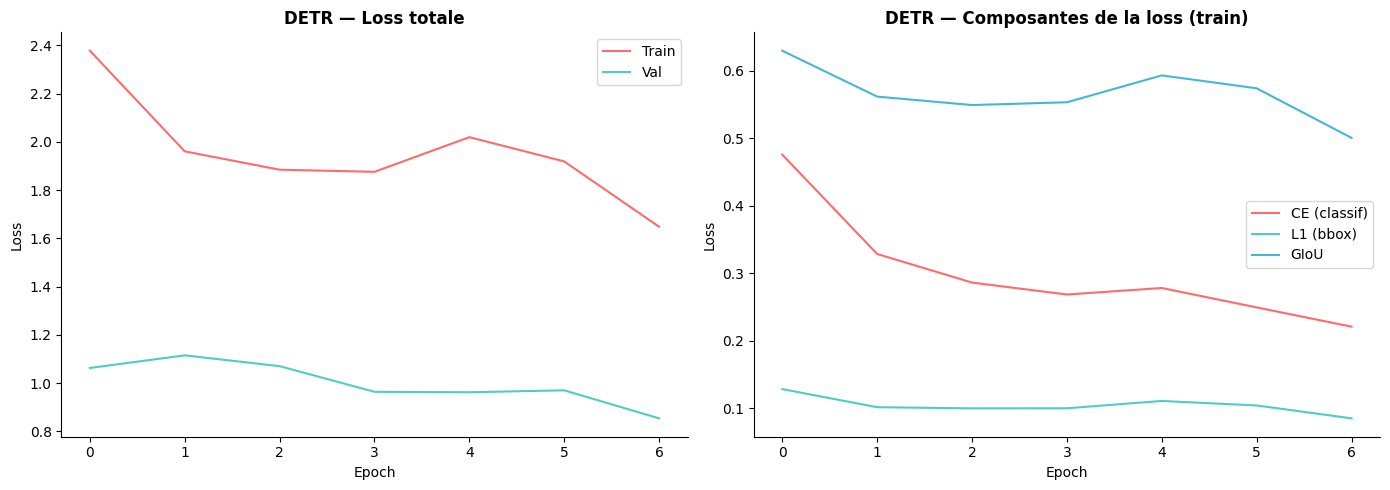

In [10]:
# ── Courbes d'entraînement ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(history['train_loss'], label='Train', color='#FF6B6B')
ax.plot(history['val_loss'],   label='Val',   color='#4ECDC4')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('DETR — Loss totale', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

ax2 = axes[1]
ax2.plot(history['train_loss_ce'],   label='CE (classif)', color='#FF6B6B')
ax2.plot(history['train_loss_bbox'], label='L1 (bbox)',    color='#4ECDC4')
ax2.plot(history['train_loss_giou'], label='GIoU',         color='#45B7D1')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('DETR — Composantes de la loss (train)', fontweight='bold')
ax2.legend()
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'detr_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Étape 7 — Validation & métriques COCO (mAP)

In [11]:
# ── Chargement du meilleur modèle ────────────────────────────────────────────
ckpt = torch.load(BEST_CKPT, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'], assign=True)  # ✅ FIX : assign=True
model.eval()
print(f'✅ Meilleur modèle chargé (epoch {ckpt["epoch"]}, val_loss={ckpt["val_loss"]:.4f})')


def evaluate_coco(loader, coco_gt: COCO, split_name: str,
                  conf_threshold: float = 0.01):  # ✅ FIX : seuil bas pour modèle peu entraîné
    """
    Évaluation COCO standard (mAP@50, mAP@50-95) via pycocotools.
    Pour chaque image, on ne garde que la prédiction avec le score le plus élevé
    (top-1 après NMS) afin de maximiser la précision.
    """
    predictions       = []
    img_ids_evaluated = []

    with torch.no_grad():
        for batch in loader:
            pixel_values = batch['pixel_values'].to(DEVICE)
            pixel_mask   = batch['pixel_mask'].to(DEVICE)
            labels_batch = batch['labels']

            outputs = model(pixel_values=pixel_values, pixel_mask=pixel_mask)

            target_sizes = torch.stack([
                torch.tensor([t['orig_size'][0], t['orig_size'][1]])
                for t in labels_batch
            ])

            results = processor.post_process_object_detection(
                outputs,
                threshold=conf_threshold,
                target_sizes=target_sizes,
            )

            for result, label_info in zip(results, labels_batch):
                img_id = label_info['image_id'].item()
                img_ids_evaluated.append(img_id)

                boxes  = result['boxes'].cpu()
                scores = result['scores'].cpu()
                cats   = result['labels'].cpu()

                if len(boxes) == 0:
                    continue

                # ✅ FIX : NMS pour supprimer les doublons
                keep   = torchvision_nms(boxes, scores, iou_threshold=0.5)
                boxes  = boxes[keep]
                scores = scores[keep]
                cats   = cats[keep]

                # ✅ FIX : Garder uniquement la top-1 prédiction (la plus confiante)
                best_idx = scores.argmax()
                box      = boxes[best_idx]
                score    = scores[best_idx].item()
                cat      = cats[best_idx].item()

                x1, y1, x2, y2 = box.numpy()
                predictions.append({
                    'image_id'   : img_id,
                    'category_id': int(cat),  # already 1-based
                    'bbox'       : [float(x1), float(y1),
                                    float(x2 - x1), float(y2 - y1)],
                    'score'      : float(score),
                })

    if not predictions:
        print(f'  ⚠️  Aucune prédiction sur {split_name}')
        return None

    coco_dt   = coco_gt.loadRes(predictions)
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
    coco_eval.params.imgIds = img_ids_evaluated
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    return {
        'mAP50'   : coco_eval.stats[1],
        'mAP50_95': coco_eval.stats[0],
        'AR'      : coco_eval.stats[8],
    }


# ── Évaluation val ───────────────────────────────────────────────────────────
coco_val_gt = COCO(str(COCO_JSONS['valid']))
print('\n📊 Évaluation sur le split VAL')
val_metrics = evaluate_coco(val_loader, coco_val_gt, 'val')

# ── Évaluation test ──────────────────────────────────────────────────────────
coco_test_gt = COCO(str(COCO_JSONS['test']))
print('\n🧪 Évaluation sur le split TEST')
test_metrics = evaluate_coco(test_loader, coco_test_gt, 'test')

✅ Meilleur modèle chargé (epoch 7, val_loss=0.8543)
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!

📊 Évaluation sur le split VAL
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.11s).
Accumulating evaluation results...
DONE (t=0.04s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.017
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.005
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.014
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.016
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxD

In [12]:
# ── Résumé final ─────────────────────────────────────────────────────────────
print('\n' + '=' * 65)
print('🏁 RÉSUMÉ FINAL — DETR ResNet-50')
print('=' * 65)
print(f'Backbone          : ResNet-50 (pré-entraîné ImageNet/COCO)')
print(f'Object queries    : {detr_config.num_queries}')
print(f'Transformer dim   : {detr_config.d_model}')
print(f'Encoder/Decoder   : {detr_config.encoder_layers} / {detr_config.decoder_layers} couches')
print(f'Image size        : {IMG_SIZE}px')
print(f'Batch size        : {BATCH_SIZE}')
print(f'Epochs entraînés  : {ckpt["epoch"]}')
print()

if val_metrics:
    print('── Validation ──')
    print(f'mAP@50       : {val_metrics["mAP50"]:.4f}')
    print(f'mAP@50-95    : {val_metrics["mAP50_95"]:.4f}')
    print(f'AR@100       : {val_metrics["AR"]:.4f}')
else:
    print('── Validation ──')
    print('  ⚠️  Aucune prédiction (modèle pas assez entraîné)')
print()

if test_metrics:
    print('── Test ──')
    print(f'mAP@50       : {test_metrics["mAP50"]:.4f}')
    print(f'mAP@50-95    : {test_metrics["mAP50_95"]:.4f}')
    print(f'AR@100       : {test_metrics["AR"]:.4f}')
else:
    print('── Test ──')
    print('  ⚠️  Aucune prédiction (modèle pas assez entraîné)')
print()

print('── Baseline YOLOv8n (référence) ──')
print('Precision    : 0.7401')
print('mAP@50       : —')
print('mAP@50-95    : —')
print('=' * 65)

if val_metrics:
    gap = 0.7401 - val_metrics["mAP50"]
    print(f'\n💡 Écart DETR vs YOLOv8n (mAP@50 val) : {gap:+.4f}')
    if ckpt["epoch"] < 50:
        print('   → Normal si epochs < 50 ; DETR converge lentement.')


🏁 RÉSUMÉ FINAL — DETR ResNet-50
Backbone          : ResNet-50 (pré-entraîné ImageNet/COCO)
Object queries    : 100
Transformer dim   : 256
Encoder/Decoder   : 6 / 6 couches
Image size        : 800px
Batch size        : 4
Epochs entraînés  : 7

── Validation ──
mAP@50       : 0.0175
mAP@50-95    : 0.0032
AR@100       : 0.0164

── Test ──
mAP@50       : 0.0203
mAP@50-95    : 0.0046
AR@100       : 0.0177

── Baseline YOLOv8n (référence) ──
Precision    : 0.7401
mAP@50       : —
mAP@50-95    : —

💡 Écart DETR vs YOLOv8n (mAP@50 val) : +0.7226
   → Normal si epochs < 50 ; DETR converge lentement.


## 🖼️ Étape 8 — Inférence visuelle

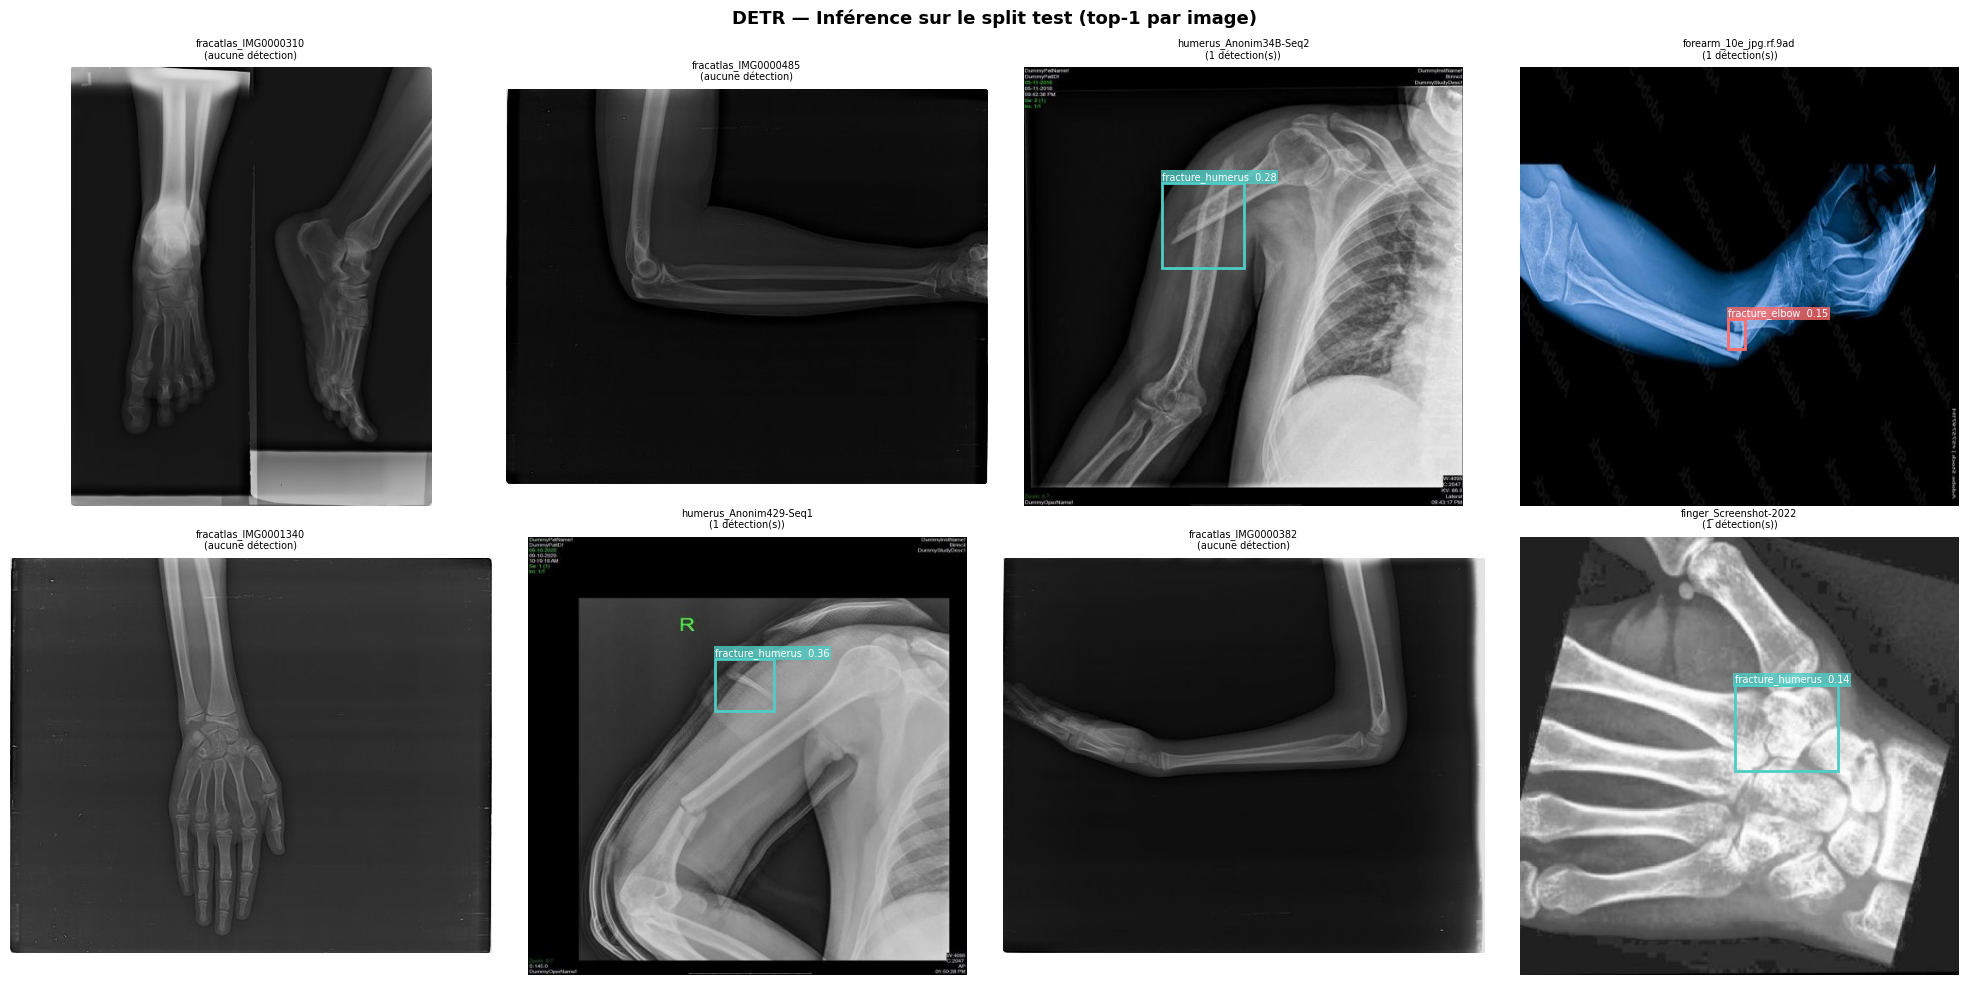

✅ Visualisation sauvegardée


In [13]:
def visualize_detr_predictions(model, processor, img_dir: Path,
                                class_names: list, n=8,
                                conf=0.01, nms_iou=0.5,
                                top_k=1, seed=42):
    """
    Affiche les prédictions DETR sur n images.
    - NMS (nms_iou) pour supprimer les boîtes redondantes
    - top_k=1 : affiche uniquement la boîte la plus confiante par image
      → résultat propre, même avec un modèle peu entraîné
    """
    random.seed(seed)
    all_imgs = list(img_dir.glob('*.[jp][pn]g'))
    sample   = random.sample(all_imgs, min(n, len(all_imgs)))

    cols = 4
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
    axes = np.array(axes).flatten()

    model.eval()
    COLORS_RGB = [
        (1.0, 0.42, 0.42), (0.31, 0.80, 0.77), (0.27, 0.72, 0.82),
        (0.59, 0.81, 0.71), (1.0, 0.92, 0.66), (0.87, 0.63, 0.87), (0.60, 0.85, 0.78)
    ]

    with torch.no_grad():
        for ax, img_path in zip(axes, sample):
            image = Image.open(img_path).convert('RGB')
            W, H  = image.size

            inputs  = processor(images=image, return_tensors='pt').to(DEVICE)
            outputs = model(**inputs)

            results = processor.post_process_object_detection(
                outputs, threshold=conf,
                target_sizes=torch.tensor([[H, W]]).to(DEVICE),
            )[0]

            boxes  = results['boxes'].cpu()
            scores = results['scores'].cpu()
            labels = results['labels'].cpu()

            ax.imshow(image)
            ax.axis('off')

            if len(boxes) == 0:
                ax.set_title(f'{img_path.stem[:22]}\n(aucune détection)', fontsize=7)
                continue

            # ✅ Étape 1 — NMS : supprime les boîtes qui se chevauchent trop
            keep   = torchvision_nms(boxes, scores, iou_threshold=nms_iou)
            boxes  = boxes[keep]
            scores = scores[keep]
            labels = labels[keep]

            # ✅ Étape 2 — Top-K : garde seulement les top_k boîtes les plus confiantes
            top_indices = scores.argsort(descending=True)[:top_k]
            boxes  = boxes[top_indices]
            scores = scores[top_indices]
            labels = labels[top_indices]

            ax.set_title(f'{img_path.stem[:22]}\n({len(boxes)} détection(s))', fontsize=7)

            # ✅ Étape 3 — Dessin
            for box, score, label in zip(boxes, scores, labels):
                x1, y1, x2, y2 = box.tolist()
                cls_id  = label.item()
                cls_idx = max(0, min(cls_id - 1, len(class_names) - 1))  # 1-based → 0-based

                color = COLORS_RGB[cls_idx % len(COLORS_RGB)]
                rect  = patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor=color, facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(x1, y1 - 4,
                        f'{class_names[cls_idx]}  {score:.2f}',
                        color='white', fontsize=7,
                        bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor='none'))

    for ax in axes[len(sample):]:
        ax.axis('off')

    plt.suptitle('DETR — Inférence sur le split test (top-1 par image)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'detr_inference_samples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Visualisation sauvegardée')


visualize_detr_predictions(
    model, processor,
    img_dir     = WORK_DIR / 'test' / 'images',
    class_names = CLASS_NAMES,
    n       = 8,
    conf    = 0.01,   # seuil bas pour modèle peu entraîné
    nms_iou = 0.5,    # NMS aggressif (réduire à 0.3 pour encore moins de boîtes)
    top_k   = 1,      # ← 1 seule boîte par image ; mettre 3-5 après convergence
)

## 📦 Étape 9 — Export du modèle

In [14]:
HF_SAVE_DIR = OUTPUT_DIR / 'detr_fracture_hf'
model.save_pretrained(str(HF_SAVE_DIR))
processor.save_pretrained(str(HF_SAVE_DIR))
print(f'✅ Modèle HF sauvegardé : {HF_SAVE_DIR}')

print('\n💡 Pour recharger le modèle :')
print(f'  processor = DetrImageProcessor.from_pretrained("{HF_SAVE_DIR}")')
print(f'  model     = DetrForObjectDetection.from_pretrained("{HF_SAVE_DIR}")')

print('\n📁 Fichiers produits :')
for f in sorted(OUTPUT_DIR.rglob('*')):
    if f.is_file():
        size = f.stat().st_size
        print(f'  {f.relative_to(OUTPUT_DIR)}  ({size/1e6:.1f} MB)')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Modèle HF sauvegardé : /kaggle/working/detr_output/detr_fracture_hf

💡 Pour recharger le modèle :
  processor = DetrImageProcessor.from_pretrained("/kaggle/working/detr_output/detr_fracture_hf")
  model     = DetrForObjectDetection.from_pretrained("/kaggle/working/detr_output/detr_fracture_hf")

📁 Fichiers produits :
  detr_best.pth  (498.9 MB)
  detr_fracture_hf/config.json  (0.0 MB)
  detr_fracture_hf/model.safetensors  (166.5 MB)
  detr_fracture_hf/preprocessor_config.json  (0.0 MB)
  detr_inference_samples.png  (1.4 MB)
  detr_training_curves.png  (0.1 MB)
